In [1]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [3]:
errors_tab = []
n_tab = []
for n in range(2, 60):
    model = KNeighborsClassifier(n_neighbors=n)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    errors = 0
    for i in range(len(y_pred)):
        if y_pred[i] != y_test[i]:
            errors = errors + 1
    n_tab.append(n)
    errors_tab.append(errors)

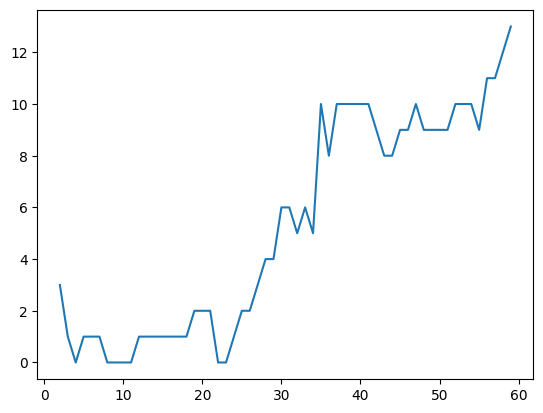

In [4]:
plt.plot(n_tab, errors_tab)

In [5]:
test_size_tab = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
errors_tab = []

for item in test_size_tab:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=item, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.fit_transform(X_test)

    model = KNeighborsClassifier(n_neighbors=10)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    errors = 0
    for i in range(len(y_pred)):
        if y_pred[i] != y_test[i]:
            errors = errors + 1
    errors_tab.append(errors)

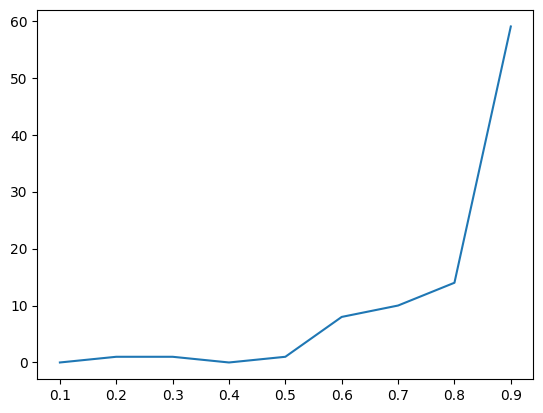

In [6]:
plt.plot(test_size_tab, errors_tab)